# Libraries

In [11]:
import torch
import pandas as pd
import numpy as np
import os
import importlib
from recbole.config import Config
from recbole.data.dataset import Dataset
from recbole.data.interaction import Interaction
from recbole.data.utils import create_dataset
#from recbole.evaluator.metrics import metrics_dict # For evaluation metrics
from recbole.utils import get_model # For simplified model loading and dir creation
from sklearn.metrics import mean_squared_error, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import json 

In [12]:
torch.cuda.is_available()

False

In [13]:
validation_file_path = '../../validation_dataset.csv'

## Model version 4: predictions 

The model training lasts 14 epochs with 'uni10' evaluation mode 

(the duration of training & evaluation was about 6 hours)

### Model configuration and eval

In [14]:

# --- Configuration for RecBole Model ---
# This dictionary holds all the configuration parameters for your NeuMF model.
# It's based on the 'prediction_config_dict_2' you provided.
MODEL_PATH = './NeuMF-May-31-2025_23-14-35.pth' 
RECBOLE_CONFIG_DICT = {
    'model': 'NeuMF',
    'dataset': 'movielens',
    'data_path': './',

  'field_separator': '\t',
    'USER_ID_FIELD': 'user_id',
    'ITEM_ID_FIELD': 'item_id',
    'RATING_FIELD': 'rating',
    'TIME_FIELD': 'timestamp',

    'load_col': {
        'inter': ['user_id', 'item_id', 'rating', 'timestamp']
    },
    'LABEL_FIELD': 'rating', 
    'threshold': {'rating': 4.5}, 

    'eval_task': 'ranking', 
    'normalize_field': {},
    'loss_type': 'BPR', 

    'eval_args': {
        'split': {'RS': [0.9, 0.05, 0.05]},
        'order': 'TO',
        'group_by': 'user',
        #'mode': {'valid': 'uni100', 'test': 'uni100'},
        'neg_sample_args': None, 
        'topk': [3, 10, 20], 
    },
    'metrics': ['Recall', 'NDCG', 'MRR'], 
    'valid_metric': 'NDCG@10',
    'valid_metric_bigger': True,

    'train_neg_sample_args': {'distribution': 'uniform', 'sample_num': 1}, 
    'mf_embedding_size': 64,
    'mlp_embedding_size': 64,
    'layers': [128, 64, 32],
    'dropout_prob': 0.3,

    'learning_rate': 0.001,
    'train_batch_size': 1024,
    'epochs': 50,
    'eval_step': 5,
    'stopping_step': 4,

    'eval_batch_size': 512,
    'log_wandb': False,
    'show_progress': False,
    'log_file': 'main_NeuMF.txt',
    'checkpoint_dir': 'main_NeuMF',
}

# --- Function to Initialize and Load the Model ---
def initialize_model(model_path: str, config_dict: dict = None) -> (torch.nn.Module, Dataset):
    """
    Initializes a RecBole model and loads its state dictionary from a checkpoint.

    Args:
        model_path (str): The path to the saved PyTorch model checkpoint (.pth file).
        config_dict (dict, optional): A dictionary containing configuration parameters
                                     for the RecBole model. If None, uses RECBOLE_CONFIG_DICT.

    Returns:
        tuple: A tuple containing:
            - model (torch.nn.Module): The loaded RecBole model.
            - dataset (recbole.data.dataset.Dataset): The dataset object initialized
                                                      with the provided configuration.
    """
    if config_dict is None:
        config_dict = RECBOLE_CONFIG_DICT.copy() # Use a copy to avoid modifying global config

    # Create RecBole Config object
    config = Config(model=config_dict['model'], dataset=config_dict['dataset'], config_dict=config_dict)

    # Create dataset object based on the config
    # This will load interaction data based on load_col, field_separator etc.
    dataset = create_dataset(config)
    print("Dataset loaded successfully.")

    # Get the model class using RecBole's utility function
    model_class = get_model(config['model'])

    # Initialize the model
    model = model_class(config, dataset)
    print(f"Model '{config['model']}' initialized.")

    # Load the model state dictionary from the checkpoint
    if not os.path.exists(model_path):
        raise FileNotFoundError(f"Model checkpoint not found at: {model_path}")

    checkpoint = torch.load(model_path, weights_only=False, map_location=torch.device('cpu')) # Load to CPU
    model.load_state_dict(checkpoint['state_dict'])
    print("Model state dictionary loaded successfully.")

    # Set model to evaluation mode
    model.eval()

    return model, dataset


In [15]:
saved_model_path = MODEL_PATH
model_init_config = RECBOLE_CONFIG_DICT.copy()

model, dataset = initialize_model(saved_model_path, model_init_config)

/opt/miniconda3/envs/movie_env/lib/python3.10/site-packages/recbole/data/dataset/dataset.py:638: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  feat[field].fillna(value=0, inplace=True)
/opt/miniconda3/envs/movie_env/lib/python3.10/site-packages/recbole/data/dataset/dataset.py:640: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we 

Dataset loaded successfully.
Model 'NeuMF' initialized.
Model state dictionary loaded successfully.


### Predictions

In [16]:

# --- Function to Make Predictions for a Single User ---
def predict_for_user(user_raw_id: str, model: torch.nn.Module, dataset: Dataset, top_n: int = 10) -> pd.DataFrame:
    """
    Generates top N item recommendations for a given user.

    Args:
        user_raw_id (str): The raw (original) ID of the user for whom to make predictions.
        model (torch.nn.Module): The initialized and loaded RecBole model.
        dataset (recbole.data.dataset.Dataset): The dataset object used by the model.
        top_n (int): The number of top recommendations to return.

    Returns:
        pd.DataFrame: A DataFrame containing 'item_id' (raw) and 'predicted_rating'
                      for the top N recommended items, sorted by predicted_rating.
    """
    print(f"\n--- Preparing predictions for user: '{user_raw_id}' ---")

    # Convert raw user ID to internal RecBole ID
    try:
        user_internal_id = dataset.token2id(dataset.uid_field, user_raw_id)
    except KeyError:
        print(f"Warning: User '{user_raw_id}' not found in the dataset.")
        return pd.DataFrame(columns=['item_id', 'predicted_rating']) # Return empty DataFrame

    # Get all item internal IDs
    all_item_internal_ids = torch.arange(dataset.item_num, dtype=torch.long).tolist()

    # Find items the user has already interacted with
    # This requires processing the entire interaction feature, which can be slow for large datasets.
    # RecBole has more optimized ways to get interacted items, but this aligns with your original code.
    user_interactions_mask = (dataset.inter_feat[dataset.uid_field] == user_internal_id)
    interacted_items_tensor = dataset.inter_feat[dataset.iid_field][user_interactions_mask]
    user_interacted_items_internal_ids = set(interacted_items_tensor.tolist())
    # print(f"User {user_raw_id} has interacted with {len(user_interacted_items_internal_ids)} items.")


    # Filter to get only the unrated items
    unrated_item_internal_ids = [
        item_id for item_id in all_item_internal_ids
        if item_id not in user_interacted_items_internal_ids
    ]

    if not unrated_item_internal_ids:
        print(f"User '{user_raw_id}' has interacted with all available items or no items to recommend.")
        return pd.DataFrame(columns=['item_id', 'predicted_rating'])

    # Prepare tensors for prediction
    user_tensor_for_prediction = torch.full(
        (len(unrated_item_internal_ids),),
        user_internal_id,
        dtype=torch.long
    )
    item_tensor_for_prediction = torch.tensor(
        unrated_item_internal_ids,
        dtype=torch.long
    )

    # Create an Interaction object for prediction
    interaction_for_prediction = Interaction({
        dataset.uid_field: user_tensor_for_prediction,
        dataset.iid_field: item_tensor_for_prediction
    })

    # Make predictions
    with torch.no_grad():
        predicted_scores = model.predict(interaction_for_prediction)

    # Map internal item IDs back to raw IDs and display results
    predictions = []
    for i, score in enumerate(predicted_scores):
        item_internal_id = unrated_item_internal_ids[i]
        item_raw_id = dataset.id2token(dataset.iid_field, item_internal_id)
        predictions.append({'item_id': item_raw_id, 'predicted_rating': score.item()})

    predictions_df = pd.DataFrame(predictions).sort_values(by='predicted_rating', ascending=False)

    print(f"\nTop {top_n} Predicted Ratings for User '{user_raw_id}':")
    print(predictions_df.head(top_n))

    return predictions_df

In [17]:
user_to_predict = '345'
predictions_df = predict_for_user(user_to_predict, model, dataset, top_n=5)



--- Preparing predictions for user: '345' ---

Top 5 Predicted Ratings for User '345':
     item_id  predicted_rating
232     2959          0.999935
228     2329          0.999676
158     4993          0.999579
1382    3897          0.999574
153     4306          0.999466


## Evaluation


In [18]:
def _predict_single_interaction(user_internal_id, item_internal_id, model, dataset):
    """
    Helper function to predict the score for a single interaction (user, item).
    """
    user_tensor = torch.tensor([user_internal_id], dtype=torch.long)
    item_tensor = torch.tensor([item_internal_id], dtype=torch.long)
    interaction = Interaction({
        dataset.uid_field: user_tensor,
        dataset.iid_field: item_tensor
    })
    with torch.no_grad():
        score = model.predict(interaction).item()
    return score

# --- Function to predict for all users in validation set ---
def predict_for_all_users_in_validation_set(model: torch.nn.Module, dataset: Dataset, validation_file_path: str) -> pd.DataFrame:
    """
    Makes predictions for each interaction (user, item) in the given validation CSV file.
    
    Args:
        model (torch.nn.Module): The loaded RecBole model.
        dataset (recbole.data.dataset.Dataset): The main dataset object used by the model,
                                                containing ID mappings.
        validation_file_path (str): Path to the validation_dataset.csv file.
        
    Returns:
        pd.DataFrame: DataFrame containing 'userId', 'movieId', 'rating', 'timestamp',
                      'predicted_score', and 'predicted_rating' columns.
    """
    print(f"\n--- Generating predictions for all users in '{validation_file_path}' ---")

    try:
        validation_df = pd.read_csv(validation_file_path)
    except FileNotFoundError:
        print(f"Error: Validation dataset not found at: {validation_file_path}")
        return pd.DataFrame()

    validation_df.rename(columns={
        'userId': RECBOLE_CONFIG_DICT['USER_ID_FIELD'],
        'movieId': RECBOLE_CONFIG_DICT['ITEM_ID_FIELD'],
        'rating': RECBOLE_CONFIG_DICT['RATING_FIELD'],
        'timestamp': RECBOLE_CONFIG_DICT['TIME_FIELD']
    }, inplace=True)

    validation_df[RECBOLE_CONFIG_DICT['USER_ID_FIELD']] = validation_df[RECBOLE_CONFIG_DICT['USER_ID_FIELD']].astype(int).astype(str)
    validation_df[RECBOLE_CONFIG_DICT['ITEM_ID_FIELD']] = validation_df[RECBOLE_CONFIG_DICT['ITEM_ID_FIELD']].astype(int).astype(str)

    all_predictions_data = []

    for index, row in validation_df.iterrows():
        user_raw_id = row[RECBOLE_CONFIG_DICT['USER_ID_FIELD']]
        item_raw_id = row[RECBOLE_CONFIG_DICT['ITEM_ID_FIELD']]
        original_rating = row[RECBOLE_CONFIG_DICT['RATING_FIELD']]
        original_timestamp = row[RECBOLE_CONFIG_DICT['TIME_FIELD']]

        try:
            user_internal_id = dataset.token2id(dataset.uid_field, user_raw_id)
            item_internal_id = dataset.token2id(dataset.iid_field, item_raw_id)
        except KeyError:
            print(f"Skipping prediction for (user={user_raw_id}, item={item_raw_id}) - not in model vocabulary.")
            continue

        predicted_score = _predict_single_interaction(user_internal_id, item_internal_id, model, dataset)
         

        all_predictions_data.append({
            'userId': user_raw_id,
            'movieId': item_raw_id,
            'rating': original_rating,
            'timestamp': original_timestamp,
            'predicted_score': predicted_score,
        })

    predictions_df_all_users = pd.DataFrame(all_predictions_data)
    print(f"Generated predictions for {len(predictions_df_all_users)} interactions from validation set.")
    return predictions_df_all_users

In [19]:
validation_file_path = '../../validation_dataset.csv'
all_users_predictions_df = predict_for_all_users_in_validation_set(model, dataset, validation_file_path)

print("\nFull prediction results for all users in validation_dataset.csv:")
print(all_users_predictions_df.head())
print(f"Total number of predictions: {len(all_users_predictions_df)}")


--- Generating predictions for all users in '../../validation_dataset.csv' ---
Generated predictions for 3808433 interactions from validation set.

Full prediction results for all users in validation_dataset.csv:
  userId movieId  rating  timestamp  predicted_score
0      5       1     4.0  858625949         0.999931
1      5      19     4.0  830786345         0.997808
2      5      32     5.0  830786277         0.999912
3      5      36     5.0  830786409         0.999754
4      5      39     2.0  858627955         0.999677
Total number of predictions: 3808433


In [20]:
def calculate_rmse(df: pd.DataFrame, true_col: str, pred_col: str, coef_: float = 1) -> float:
    if df.empty:
        print("DataFrame is empty, RMSE cannot be calculated.")
        return np.nan
    rmse_value = np.sqrt(mean_squared_error(df[true_col], df[pred_col]*coef_))
    return rmse_value

# --- Function to Plot AUC and ROC Curve ---
def calculate_auc_plot(df: pd.DataFrame, true_rating_col: str, predicted_score_col: str, good_movie_threshold: float = 4.5):
    """
    Calculates AUC and plots the ROC curve,
    defining a "good movie" based on a rating threshold.

    Args:
        df (pd.DataFrame): DataFrame containing true ratings and predicted scores.
        true_rating_col (str): Name of the column with true ratings.
        predicted_score_col (str): Name of the column with predicted scores (raw, unscaled).
        good_movie_threshold (float): Threshold for defining a "good movie".
    """
    print(f"\n--- Calculating AUC and plotting ROC curve ---")
    if df.empty:
        print("DataFrame is empty, AUC cannot be calculated and ROC curve cannot be plotted.")
        return

    true_labels = (df[true_rating_col] >= good_movie_threshold).astype(int)
    predicted_scores = df[predicted_score_col]

    if len(true_labels.unique()) < 2:
        print("Error: AUC calculation requires at least two classes (good/bad movies).")
        return
    if len(true_labels) == 0:
        print("Error: No data to calculate AUC.")
        return

    auc_value = roc_auc_score(true_labels, predicted_scores)
    print(f"AUC (good movie threshold >= {good_movie_threshold}): {auc_value:.4f}")

    fpr, tpr, thresholds = roc_curve(true_labels, predicted_scores)
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {auc_value:.4f})')
    plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (FPR)')
    plt.ylabel('True Positive Rate (TPR)')
    plt.title('ROC Curve for "Good Movie" Prediction')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

RMSE: 1.7193 if scaled to 5.0 rating scale.

--- Calculating AUC and plotting ROC curve ---
AUC (good movie threshold >= 4.5): 0.6192


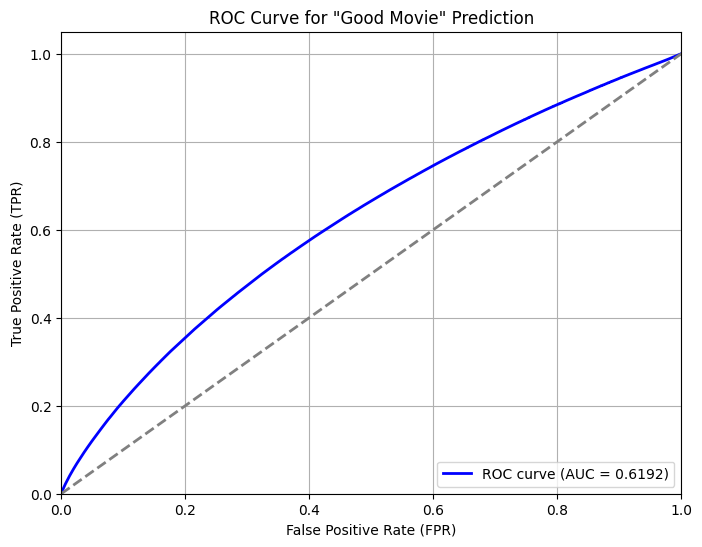

In [21]:
rmse_result = calculate_rmse(all_users_predictions_df, 'rating', 'predicted_score',5)
print(f"RMSE: {rmse_result:.4f} if scaled to 5.0 rating scale.")

# Расчет и построение AUC
# Используем 'rating' для истинных меток и 'predicted_score' для предсказанных вероятностей/оценок.
# Порог для "хорошего фильма" взят из RECBOLE_CONFIG_DICT.
auc_plot_result = calculate_auc_plot(all_users_predictions_df, 'rating', 'predicted_score', 
                                        good_movie_threshold=4.5)


In [22]:
for i in np.arange(3, 5.1, 0.1):
    rmse_result = calculate_rmse(all_users_predictions_df, 'rating', 'predicted_score', i)
    print(f"{i:.1f}) RMSE: {rmse_result:.4f}")

3.0) RMSE: 1.2850
3.1) RMSE: 1.2411
3.2) RMSE: 1.2033
3.3) RMSE: 1.1723
3.4) RMSE: 1.1485
3.5) RMSE: 1.1324
3.6) RMSE: 1.1243
3.7) RMSE: 1.1245
3.8) RMSE: 1.1328
3.9) RMSE: 1.1492
4.0) RMSE: 1.1733
4.1) RMSE: 1.2047
4.2) RMSE: 1.2427
4.3) RMSE: 1.2868
4.4) RMSE: 1.3364
4.5) RMSE: 1.3909
4.6) RMSE: 1.4498
4.7) RMSE: 1.5125
4.8) RMSE: 1.5786
4.9) RMSE: 1.6476
5.0) RMSE: 1.7193


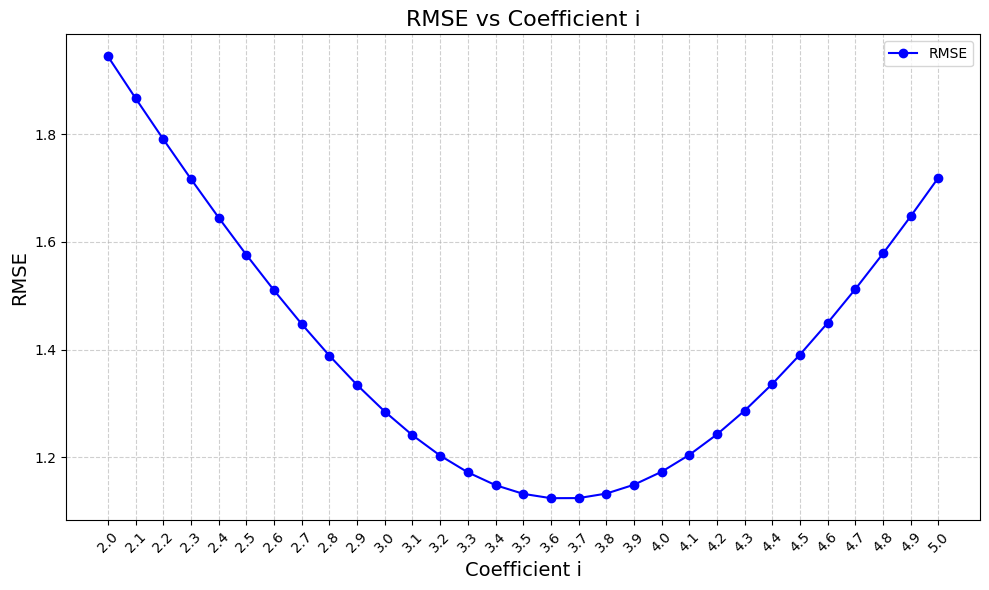

In [23]:
i_values = np.arange(2, 5.1, 0.1)
rmse_values = []

for i in i_values:
    rmse_result = calculate_rmse(all_users_predictions_df, 'rating', 'predicted_score', i)
    rmse_values.append(rmse_result)


plt.figure(figsize=(10, 6))
plt.plot(i_values, rmse_values, marker='o', linestyle='-', color='blue', label='RMSE')

plt.title('RMSE vs Coefficient i', fontsize=16)
plt.xlabel('Coefficient i', fontsize=14)
plt.ylabel('RMSE', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(np.round(i_values, 1), rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [24]:
def predict_for_cold_start_user_from_json(model: torch.nn.Module, dataset: Dataset, user_ratings_file: str) -> pd.DataFrame:
    """
    Generates predictions for a new (cold-start) user whose ratings are provided in a JSON file.
    This function creates a synthetic user embedding by averaging the embeddings of items
    the user has rated, then uses this to predict scores for unrated items.

    Args:
        model (torch.nn.Module): The loaded RecBole model.
        dataset (recbole.data.dataset.Dataset): The main dataset object used by the model,
                                                containing ID mappings.
        user_ratings_file (str): Path to the user_ratings.json file.

    Returns:
        pd.DataFrame: DataFrame containing 'movieId', 'predicted_score', and 'predicted_rating'
                      for the unrated items, sorted by predicted_rating.
    """
    print(f"\n--- Generating predictions for a new (cold-start) user from '{user_ratings_file}' ---")

    try:
        with open(user_ratings_file, 'r') as f:
            user_raw_ratings = json.load(f)
    except FileNotFoundError:
        print(f"Error: User ratings file not found at: {user_ratings_file}")
        return pd.DataFrame()
    except json.JSONDecodeError:
        print(f"Error: Could not decode JSON from {user_ratings_file}. Ensure it's valid JSON.")
        return pd.DataFrame()

    rated_item_raw_ids = [str(k) for k in user_raw_ratings.keys()]
    
    # Convert raw item IDs to internal IDs
    rated_item_internal_ids = []
    for item_raw_id in rated_item_raw_ids:
        try:
            internal_id = dataset.token2id(dataset.iid_field, item_raw_id)
            rated_item_internal_ids.append(internal_id)
        except KeyError:
            print(f"Warning: Item '{item_raw_id}' from user_ratings.json not found in model's item vocabulary. Skipping.")
    
    if not rated_item_internal_ids:
        print("No valid rated items found in the user's history for prediction.")
        return pd.DataFrame()

    # Get item embeddings for the rated items
    if not hasattr(model, 'item_mf_embedding') or not hasattr(model, 'item_mlp_embedding'):
        print("Error: Model does not have expected item embedding layers (item_mf_embedding, item_mlp_embedding). Cannot derive synthetic user embedding.")
        return pd.DataFrame()

    # Move embeddings to CPU for numpy operations if they are on GPU
    item_mf_embeddings = model.item_mf_embedding.weight.data[rated_item_internal_ids].cpu()
    item_mlp_embeddings = model.item_mlp_embedding.weight.data[rated_item_internal_ids].cpu()

    # Create a synthetic user embedding by averaging the rated item embeddings
    synthetic_user_mf_embedding = item_mf_embeddings.mean(dim=0, keepdim=True)
    synthetic_user_mlp_embedding = item_mlp_embeddings.mean(dim=0, keepdim=True)

    # Prepare all unrated items for prediction
    # We start from 1 because item_id 0 is typically a padding item in RecBole
    all_item_internal_ids = torch.arange(1, dataset.item_num, dtype=torch.long)
    unrated_item_internal_ids = [
        item_id for item_id in all_item_internal_ids.tolist()
        if item_id not in rated_item_internal_ids
    ]
    
    if not unrated_item_internal_ids:
        print("No unrated items to recommend for this user.")
        return pd.DataFrame()

    candidate_item_internal_ids_tensor = torch.tensor(unrated_item_internal_ids, dtype=torch.long)

    # Get MF and MLP embeddings for all candidate items
    candidate_item_mf_embeddings = model.item_mf_embedding.weight.data[candidate_item_internal_ids_tensor].cpu()
    candidate_item_mlp_embeddings = model.item_mlp_embedding.weight.data[candidate_item_internal_ids_tensor].cpu()

    # Combine synthetic user embeddings with candidate item embeddings
    expanded_user_mf_embedding = synthetic_user_mf_embedding.expand_as(candidate_item_mf_embeddings)
    expanded_user_mlp_embedding = synthetic_user_mlp_embedding.expand_as(candidate_item_mlp_embeddings)

    # Pass through NeuMF's prediction layers (mimicking NeuMF's forward pass)
    with torch.no_grad():
        mf_vector = expanded_user_mf_embedding * candidate_item_mf_embeddings
        mlp_vector = torch.cat((expanded_user_mlp_embedding, candidate_item_mlp_embeddings), dim=-1)
        mlp_vector = model.mlp_layers(mlp_vector)
        output_vector = torch.cat((mf_vector, mlp_vector), dim=-1)
        predicted_scores_tensor = model.predict_layer(output_vector).squeeze(-1)

    predicted_scores = predicted_scores_tensor.tolist()

    predictions_data = []
    for i, score in enumerate(predicted_scores):
        item_internal_id = unrated_item_internal_ids[i]
        item_raw_id = dataset.id2token(dataset.iid_field, item_internal_id)
        predicted_rating_scaled = score * 5
        predictions_data.append({
            'movieId': item_raw_id,
            'predicted_score': score,
            'predicted_rating': predicted_rating_scaled
        })

    predictions_df = pd.DataFrame(predictions_data).sort_values(by='predicted_rating', ascending=False)
    print(f"Generated {len(predictions_df)} predictions for the new user.")
    return predictions_df

In [25]:
user_ratings_json_path = '../../user_ratings.json'

cold_start_predictions_df = predict_for_cold_start_user_from_json(model, dataset, user_ratings_json_path)

print("\nPredictions for the new (cold-start) user:")
if not cold_start_predictions_df.empty:
    print(cold_start_predictions_df.head())
    print(f"Total cold-start predictions: {len(cold_start_predictions_df)}")
else:
    print("No cold-start predictions generated.")


--- Generating predictions for a new (cold-start) user from '../../user_ratings.json' ---
Generated 59045 predictions for the new user.

Predictions for the new (cold-start) user:
      movieId  predicted_score  predicted_rating
22648  165877        -1.515750         -7.578752
29996  123842        -1.524796         -7.623982
12092    7809        -1.531524         -7.657620
38282  126931        -1.552640         -7.763200
37003   88315        -1.557025         -7.785124
Total cold-start predictions: 59045
